Model yang digunakan adalah K-Nearest Neighbor (KNN) untuk mengklasifikasikan suara menjadi male dan female. Data dibagi menjadi data training dan testing dengan perbandingan 80:20. Sebelum proses klasifikasi dilakukan standardisasi fitur menggunakan StandardScaler.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Membaca dataset
df = pd.read_csv('voice.csv')

# Memisahkan fitur dan label
X = df.drop('label', axis=1)
y = df['label']

# Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Membuat model KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Training
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print('Akurasi:', accuracy)

Akurasi: 0.9763406940063092


In [43]:
X = df.drop('label', axis=1)
y = df['label']

X_train_original, X_test_original, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Berdasarkan percobaan pemilihan fitur, enam fitur yang digunakan adalah sd, Q25, IQR, sp.ent, sfm, dan meanfun. Fitur tersebut dipilih karena memberikan performa klasifikasi yang tinggi dibandingkan penggunaan seluruh fitur.

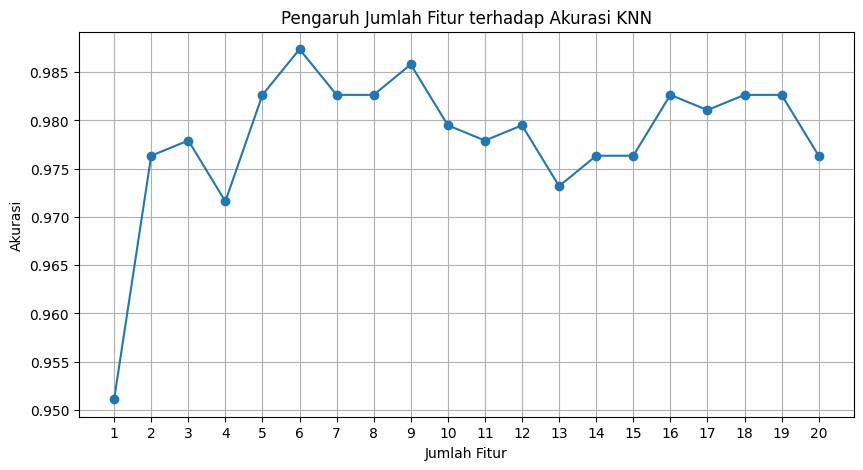

In [44]:
from sklearn.feature_selection import SelectKBest, f_classif

hasil_fitur = []

for jumlah_fitur in range(1, 21):

    selector = SelectKBest(f_classif, k=jumlah_fitur)

    X_train_selected = selector.fit_transform(
        X_train_original, y_train
    )
    X_test_selected = selector.transform(X_test_original)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_test_scaled = scaler.transform(X_test_selected)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_scaled, y_train)

    prediksi = knn.predict(X_test_scaled)

    akurasi = accuracy_score(y_test, prediksi)

    hasil_fitur.append(akurasi)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), hasil_fitur, marker='o')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')
plt.title('Pengaruh Jumlah Fitur terhadap Akurasi KNN')
plt.xticks(range(1, 21))
plt.grid()
plt.show()